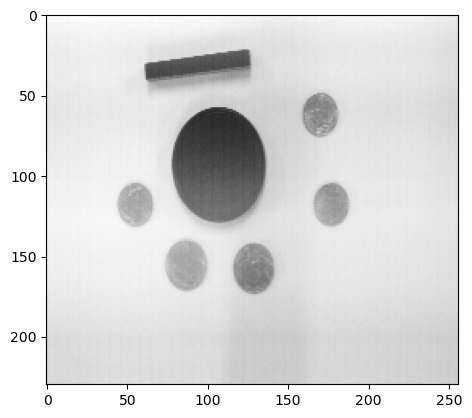

In [90]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/MORPHO.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

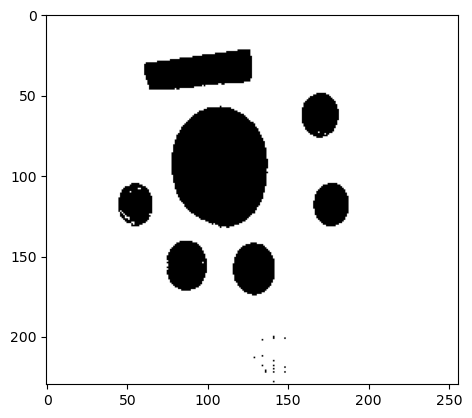

In [91]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

#Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).
ret,umbralizada = cv.threshold(image,115,255,cv.THRESH_BINARY)

plt.imshow(umbralizada, cmap="gray")
plt.show()

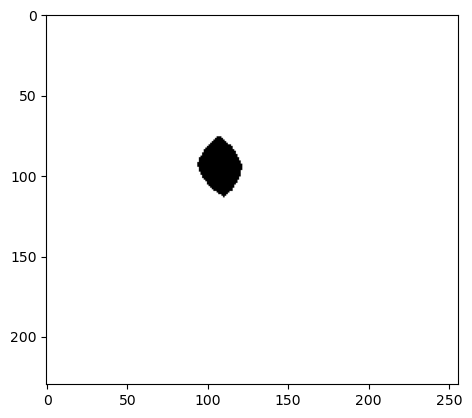

In [92]:
#Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29.

from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle

fp = footprint_rectangle((29,29))

dilated_image = dilation(umbralizada, footprint=fp)

plt.imshow(dilated_image, cmap="gray", vmin=0, vmax=255)
plt.show()

¿Qué obtiene como resultado?

Tenemos como resultado que desaparecen nuestros objetos negros, como estamos dilatando los objetos claros (el fondo), basicamente entonces el fondo se "comió" a los objetos negros mas pequeños

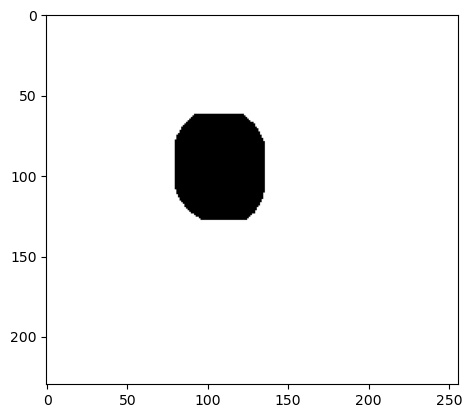

In [93]:
#Sobre la imagen resultante, haga una erosión con la misma máscara.

fp = footprint_rectangle((29,29))

erosion_image = erosion(dilated_image, footprint=fp)

plt.imshow(erosion_image, cmap="gray", vmin=0, vmax=255)
plt.show()


¿Cómo es el objeto obtenido con respecto al original?

Los objetos mas pequeños desaparecieron, quedo el objeto negro mas grande, pero al aplicar erosion los objetos blancos van a reducirse, esto expone mas pixeles del objeto negro y por eso aumenta su tamaño

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


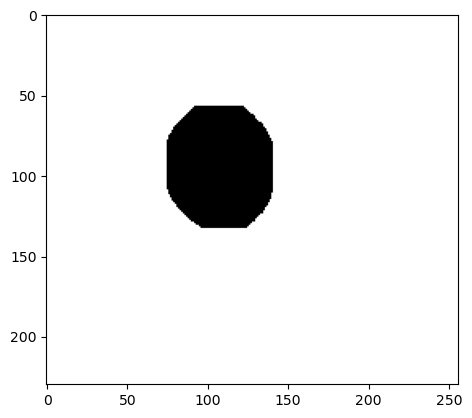

In [ ]:
#Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11

fp = np.empty((11,11))

fp[5, :] = 1
fp[:, 5] = 1

print(fp)

erosion_image_2 = erosion(erosion_image, footprint=fp)

plt.imshow(erosion_image_2, cmap="gray", vmin=0, vmax=255)
plt.show()




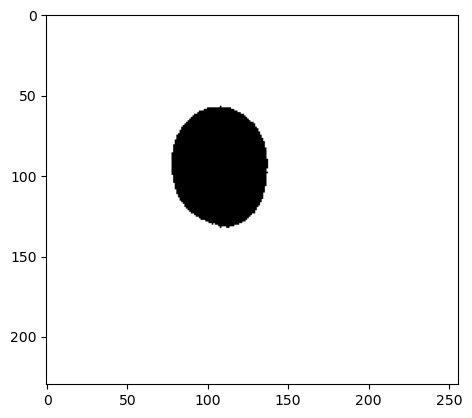

In [95]:
#Calcule el máximo entre esta última imagen y la imagen original umbralizada

resultado = cv2.max(erosion_image_2, umbralizada)

plt.imshow(resultado, cmap="gray")
plt.show()

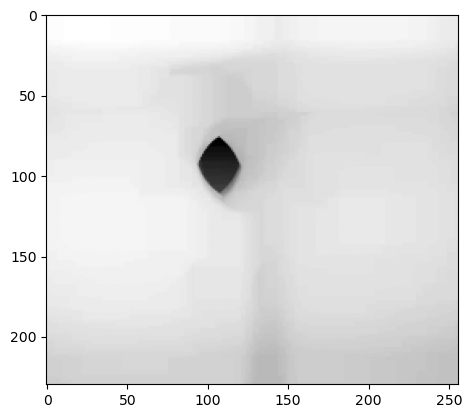

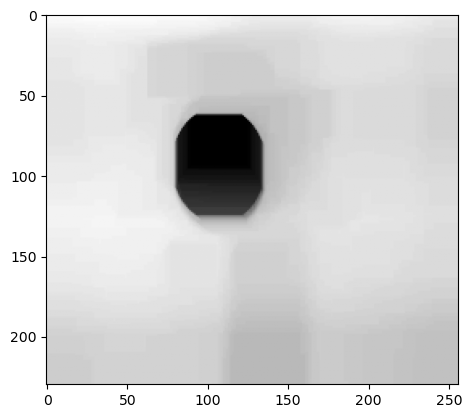

In [100]:
#Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

#Sobre la imagen original efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29.

from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle

fp = footprint_rectangle((29,29))

dilated_image = dilation(image, footprint=fp)

plt.imshow(dilated_image, cmap="gray")
plt.show()

#Sobre la imagen resultante, haga una erosión con la misma máscara.

fp = footprint_rectangle((29,29))

erosion_image = erosion(dilated_image, footprint=fp)

plt.imshow(erosion_image, cmap="gray")
plt.show()

